### Import dependencies
- Load essential libraries for modeling, evaluation, explainability, and file handling.
- `XGBClassifier`: the primary model used.
- `shap`: for interpreting predictions.
- `product`: used for manual hyperparameter grid creation.
- `joblib`: for saving the trained model.
- `os`: for directory operations.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, accuracy_score
)
import shap
from itertools import product
import joblib
import os

### Set up file paths and output directories
- Define the path for the panel dataset (VIF-normalized).
- Specify output paths for saving trained models, SHAP values, evaluation metrics, and feature importances.
- Automatically create those directories if they don’t already exist.

In [33]:
DATA_PATH = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
MODEL_DIR = "../models"
IMPORTANCE_DIR = "../data/feature_importance"
SHAP_DIR = "../data/shap_values"
METRICS_DIR = "../data/model_performance/per_country"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(IMPORTANCE_DIR, exist_ok=True)
os.makedirs(SHAP_DIR, exist_ok=True)

### General configuration
- `DROP_COLS`: columns to exclude from the feature matrix.
- `TARGETS`: all target labels to be modeled — one will be selected per run.
- `RANDOM_STATE`: seed for reproducibility.
- `TEST_SIZE`: percentage of data reserved for the test set.


In [34]:
DROP_COLS = ['date', 'Country']
TARGETS = ["RECESS", "RECESS_OVER", "RECESS_PERIOD"]
RANDOM_STATE = 42
TEST_SIZE = 0.2

### Load dataset and initialize results container
- Read the VIF-normalized panel dataset from Excel.
- Convert `date` column to datetime for time-based filtering.
- Initialize `all_results` to store evaluation metrics from this run.

In [35]:
df = pd.read_excel(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
# Results
all_results = []

### Set training, validation, and test periods
- Define the time-based split boundaries:
  - Training: 1995–2009
  - Validation: 2010–2018
  - Test: 2019–2025 (or latest)


In [36]:
train_start = "1995-01-01"
train_end   = "2009-12-31"
val_end     = "2018-12-31"
test_end    = "2025-05-31"

### Pick target variable
- Choose one of the three classification targets:
  - `RECESS`, `RECESS_OVER`, or `RECESS_PERIOD`.
- Used to define the label (`y`) for training and evaluation.


In [37]:
target = "RECESS"

### Create time-based masks
- Generate boolean masks using the `date` column for:
  - `train_mask`: rows within training period.
  - `val_mask`: rows within validation period.
  - `test_mask`: rows within test period.


In [38]:
# Drop non-feature columns (drop all targets + drop_cols)
X = df.drop(columns=DROP_COLS + TARGETS)
y = df[target]

# Filter each split based on the 'date' column
train_mask = (df['date'] >= train_start) & (df['date'] <= train_end)
val_mask   = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask  = (df['date'] > val_end) & (df['date'] <= test_end)

### Create time-based masks
- Generate boolean masks using the `date` column for:
  - `train_mask`: rows within training period.
  - `val_mask`: rows within validation period.
  - `test_mask`: rows within test period.

In [40]:
X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

### Visualizing splits
- Quickly inspect which columns are being used for model training.


In [41]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df[train_mask]['date'].min().date()} to {df[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df[val_mask]['date'].min().date()} to {df[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df[test_mask]['date'].min().date()} to {df[test_mask]['date'].max().date()}")

Train: 1080 samples
Validation: 648 samples
Test: 390 samples
Train Date Range: 1995-01-01 to 2009-12-01
Validation Date Range: 2010-01-01 to 2018-12-01
Test Date Range: 2019-01-01 to 2024-05-01


### Compute scale_pos_weight for class imbalance
- Calculate the ratio of negative to positive samples in the training set.
- This value will be used to test a cost-sensitive version of the model.


In [42]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"[INFO] scale_pos_weight set to: {scale_pos_weight:.2f}")

[INFO] scale_pos_weight set to: 1.55


### Define hyperparameter grid for tuning
- Create a manual parameter grid for XGBoost tuning.
- Includes:
  - Estimators, depth, learning rate, subsample rates
  - `scale_pos_weight` to test different cost-sensitive configurations

In [43]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'scale_pos_weight': [1, 5, 10, 20, scale_pos_weight]
}

### Build all parameter combinations
- Create a list of all hyperparameter combinations using `itertools.product`.


In [44]:
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in product(*values)]

### Initialize tuning placeholders
- Prepare variables to track the best model, F1 score, threshold, and parameters.


In [45]:
best_model = None
best_thresh = 0.5
best_f1 = 0
best_params = None

### Train and tune XGBoost over all parameter combinations
- For each hyperparameter combo:
  - Train a model.
  - Predict probabilities on validation set.
  - Perform threshold tuning (0.10 to 0.89) to find best F1 score.
  - Track and store the best model + configuration.


In [46]:
for combo in combinations:
    model = XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        **combo
    )
    model.fit(X_train, y_train)

    # Predict on validation set
    y_val_prob = model.predict_proba(X_val)[:, 1]

    # Threshold tuning
    for t in np.arange(0.1, 0.9, 0.01):
        y_val_pred = (y_val_prob > t).astype(int)
        f1 = f1_score(y_val, y_val_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
            best_model = model
            best_params = combo

Trying combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 1}
Trying combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 5}
Trying combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 10}
Trying combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 20}
Trying combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': np.float64(1.553191489361702)}
Trying combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1, 'scale_pos_weight': 1}
Trying combo: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1, 'scale_pos

### Print best model results from validation tuning
- Show the highest F1 score, best threshold, and optimal hyperparameters found during tuning.

In [47]:
print(f"[TUNED] Best F1 on val: {best_f1:.3f}")
print(f"[TUNED] Best threshold: {best_thresh}")
print(f"[TUNED] Best hyperparameters: {best_params}")

[TUNED] Best F1 on val: 0.675
[TUNED] Best threshold: 0.4099999999999998
[TUNED] Best hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 10}


### Generate predictions on test set
- Use the best model and best threshold from validation to create final predictions.


In [48]:
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob > best_thresh).astype(int)

### Evaluate test set performance
- Compute key evaluation metrics:
  - AUC, F1, Precision, Recall, Accuracy

In [49]:
auc = roc_auc_score(y_test, y_test_prob)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)

### Print test results
- Output the test metrics with proper formatting.

In [50]:
print(f"[TEST] AUC: {auc:.3f} | F1: {f1:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f} | Accuracy: {accuracy:.3f}")

[TEST] AUC: 0.633 | F1: 0.443 | Precision: 0.285 | Recall: 0.990 | Accuracy: 0.349


### Add final evaluation to results table
- Append the current run’s performance (including threshold and scale_pos_weight) to the `all_results` list.

In [51]:
all_results.append({
    "Target": target,
    "AUC": auc,
    "F1": best_f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Threshold": best_thresh,
    "Cost_Sensitive_Rate": combo.get("scale_pos_weight", "N/A")
})

In [52]:
results_df = pd.DataFrame(all_results)
results_df

,Target,AUC,F1,Precision,Recall,Accuracy,Threshold,Cost_Sensitive_Rate
0,RECESS,0.633068,0.675393,0.285311,0.990196,0.348718,0.41,1.553191


### Save the results on a file

In [53]:
results_path = f"{METRICS_DIR}/XGB_GRID__results.csv"
results_df.to_csv(results_path, index=False)

print(f"[INFO] Results saved to: {results_path}")

[INFO] Results saved to: ../data/model_performance/per_country/XGB_per_country_email_results.csv


### Feature importance
- Begin extraction and analysis of feature importances from the trained model.


In [54]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

importance_path = os.path.join(IMPORTANCE_DIR, f"XGB_GRID_{target}_importance.csv")
importances.to_csv(importance_path)

print(f"[INFO] Feature importance saved: {importance_path}")

[INFO] Feature importance saved: ../data/feature_importance\XGB_RECESS_importance.csv


### SHAP
- Use SHAP’s `Explainer` to compute how much each feature contributed to each prediction in the training set.
- Works by comparing model outputs with and without each feature.

In [55]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

### Aggregate SHAP values
- Store SHAP values in a DataFrame where:
  - Each row corresponds to a training sample.
  - Each column corresponds to a feature.
- Calculate the mean absolute SHAP value for each feature to determine overall importance.
- Sort features from most to least impactful.


In [56]:
shap_df = pd.DataFrame(shap_values.values, columns=X_train.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)
shap_path = os.path.join(SHAP_DIR, f"XGB_GRID_SHAP_{target}.csv")
mean_shap.to_csv(shap_path)
print(f"[INFO] SHAP CSV saved: {shap_path}")

[INFO] SHAP CSV saved: ../data/shap_values\XGB_SHAP_RECESS.csv


### Generate SHAP bar plot
- Create a bar plot showing the top features ranked by average SHAP impact.
- Helps visually identify which variables most influenced the model.

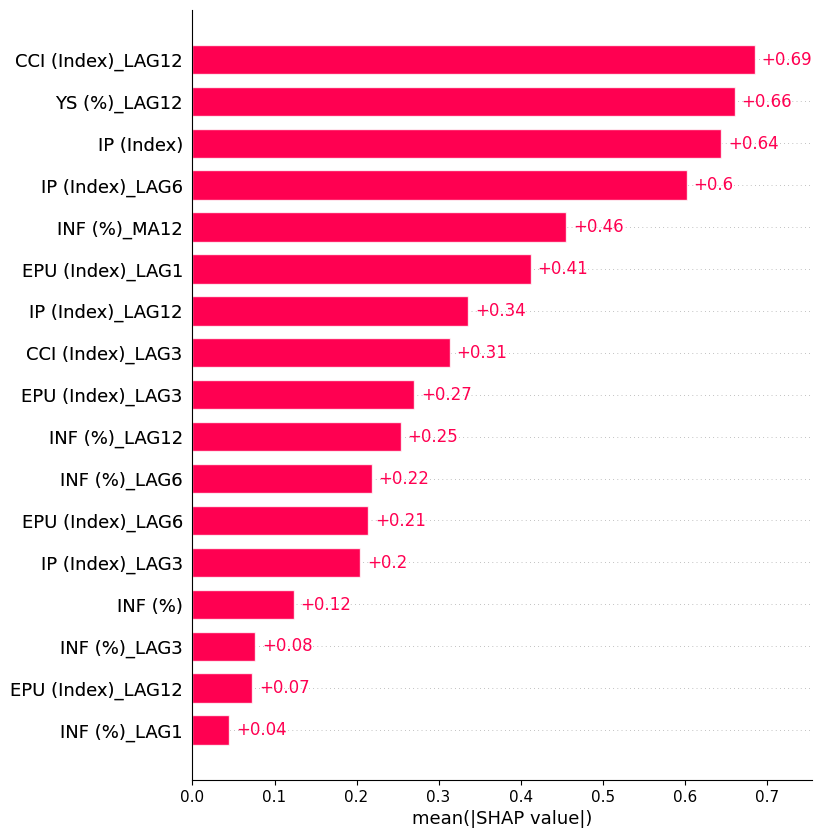

In [57]:
# No need to slice for class 1 — already 2D
shap_values_array = shap_values.values

# Create a summary bar plot with top 20 features
shap.plots.bar(
    shap.Explanation(values=shap_values_array,
                     base_values=shap_values.base_values,
                     data=X_train.values,
                     feature_names=X_train.columns),
    max_display=20,
    show=True
)

In [59]:
shap_plot_path = os.path.join(SHAP_DIR, f"XGB_GRID_SHAP_barplot_{target}.png")
plt.savefig(shap_plot_path, bbox_inches='tight', dpi=300)
print(f"[INFO] SHAP bar plot saved: {shap_plot_path}")
plt.close()

[INFO] SHAP bar plot saved: ../data/shap_values\XGB_SHAP_barplot_RECESS.png


### Generate SHAP beeswarm plot
- Use SHAP’s beeswarm plot to display the full distribution of feature impacts.
- Each dot represents one instance; color shows feature value.
- This highlights both the strength and direction of influence for each feature.

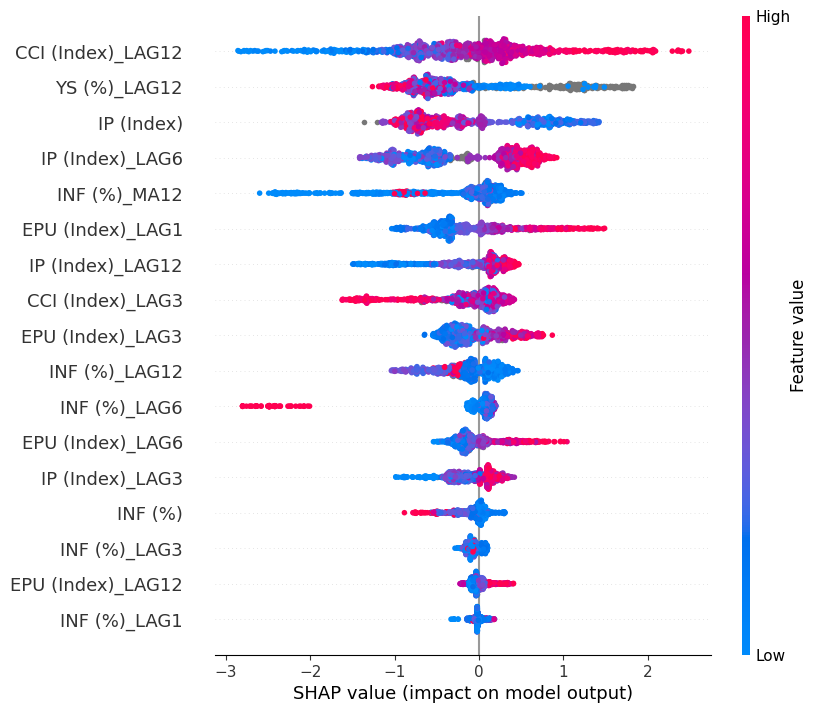

In [60]:
shap.plots.beeswarm(shap_values, max_display=20, show=True)

In [61]:
shap_plot_path = os.path.join(SHAP_DIR, f"XGB_GRID_SHAP_beeswarm_{target}.png")
plt.tight_layout()
plt.savefig(shap_plot_path, bbox_inches='tight', dpi=300)
print(f"[INFO] SHAP beeswarm plot saved: {shap_plot_path}")
plt.close()

[INFO] SHAP beeswarm plot saved: ../data/shap_values\XGB_SHAP_beeswarm_RECESS.png


### Generate SHAP interaction plot
- Create a SHAP interaction summary plot.
- Shows how pairs of features jointly affect the model’s output.
- Useful for uncovering second-order effects not visible in bar or beeswarm plots.

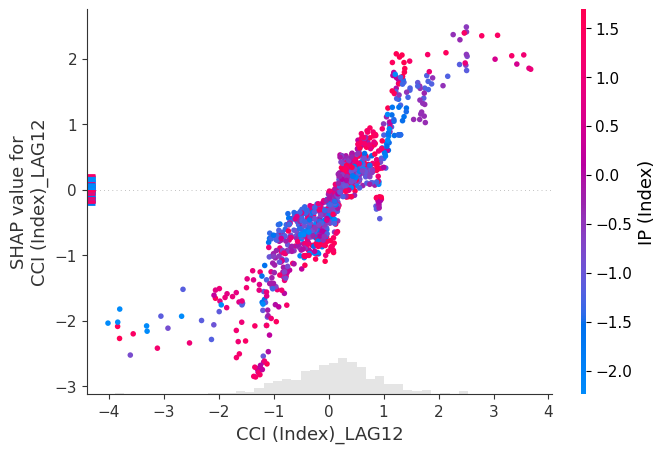

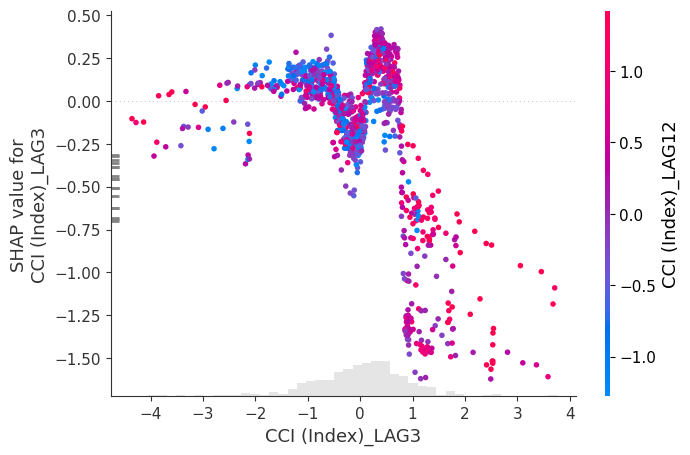

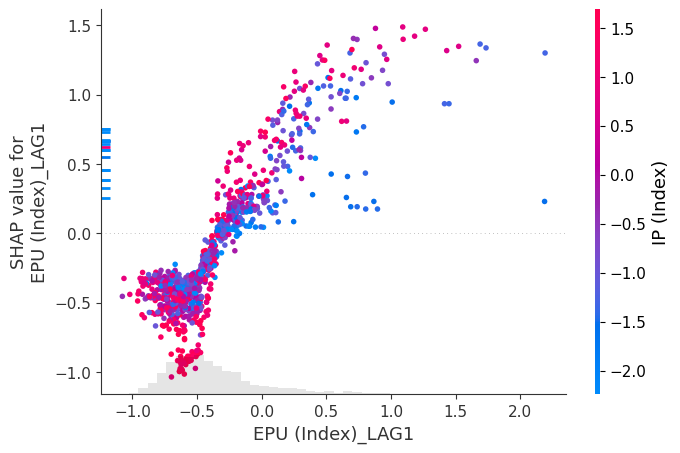

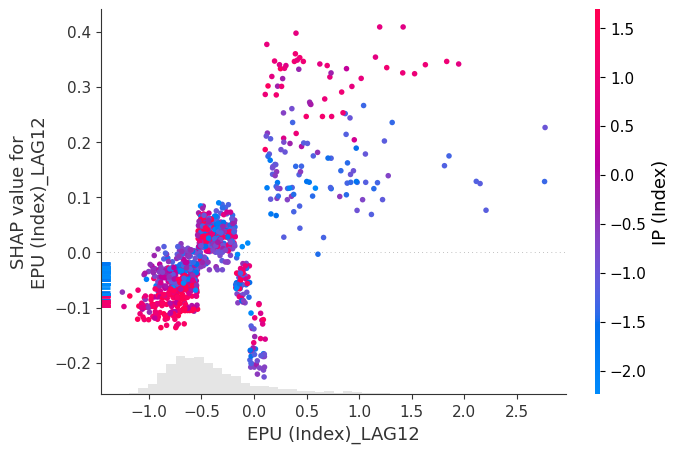

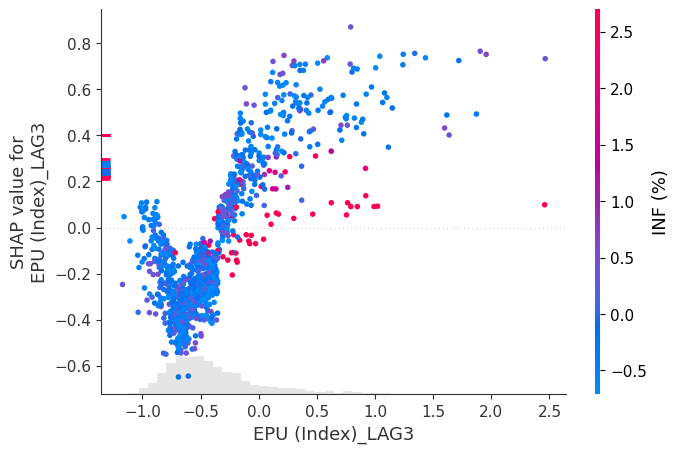

In [62]:
top_features = shap_values.feature_names[:5]

for feature in top_features:
    shap.plots.scatter(shap_values[:, feature], color=shap_values)

In [63]:
shap_plot_path = os.path.join(SHAP_DIR, f"XGB_GRID_SHAP_TOP_FEATURES_{target}.png")
plt.tight_layout()
plt.savefig(shap_plot_path, bbox_inches='tight', dpi=300)
print(f"[INFO] SHAP top features plot saved: {shap_plot_path}")
plt.close()

[INFO] SHAP top features plot saved: ../data/shap_values\XGB_SHAP_TOP_FEATURES_RECESS.png


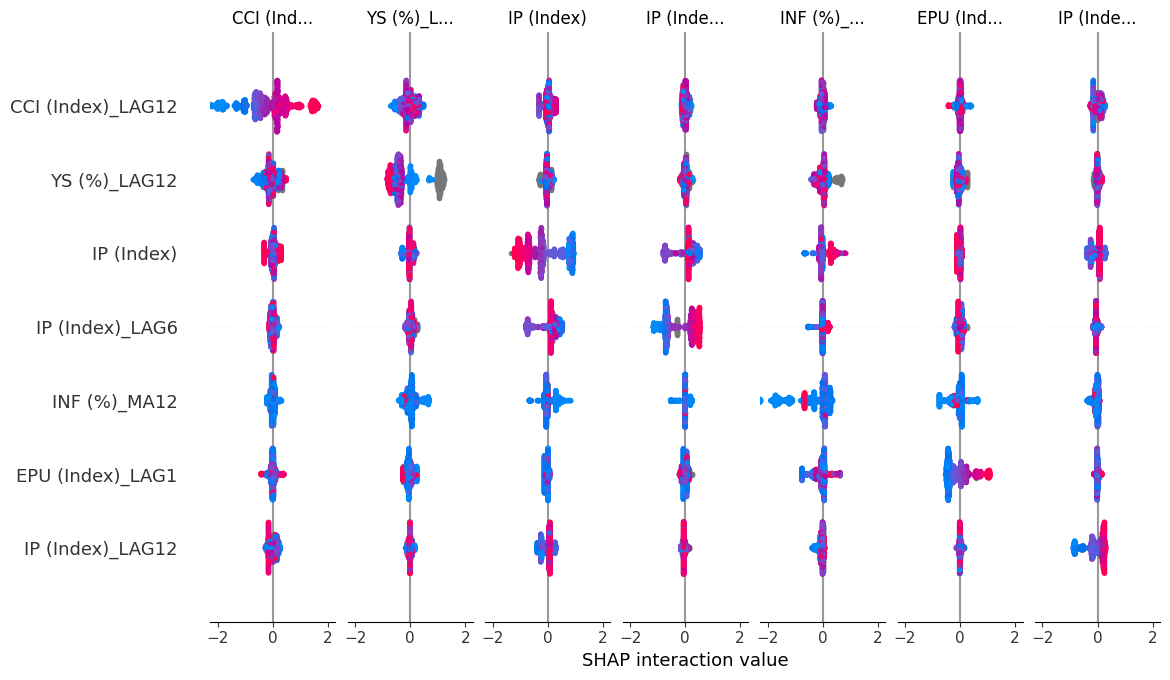

In [64]:
interaction_values = shap.TreeExplainer(best_model).shap_interaction_values(X_train)

# Plot interaction summary
shap.summary_plot(interaction_values, X_train)

In [65]:
shap_plot_path = os.path.join(SHAP_DIR, f"XGB_GRID_INTERACTION_{target}.png")
plt.tight_layout()
plt.savefig(shap_plot_path, bbox_inches='tight', dpi=300)
print(f"[INFO] SHAP interaction plot saved: {shap_plot_path}")
plt.close()

[INFO] SHAP interaction plot saved: ../data/shap_values\XGB_INTERACTION_RECESS.png


### Save the model


In [66]:
model_path = os.path.join(MODEL_DIR, f"XGB_GRID_model_{target}.pkl")
joblib.dump(model, model_path)

print(f"[INFO] Model saved: {model_path}")

[INFO] Model saved: ../models\XGB_model_RECESS.pkl
